# Phase A-1: 构建 User Latent Factors

## 目标
基于 Phase A-0 的偏好画像，为每个用户计算 7 个 latent factor（location_preference 已砍掉）。

## 7 个 Factor
| # | Factor | 维度 | 来源 |
|---|--------|------|------|
| 1 | content_type_pref | 3 | 用户 item 的 content_type 分布 |
| 2 | theme_affinity | 50 | theme 分布矩阵 → TruncatedSVD 降维 |
| 3 | quality_sensitivity | 1 | 用户 rate vs item quality 的相关性 |
| 4 | budget_level | 1 | 用户 level + 消费能力的综合 |
| 5 | skill_match_vector | 32 | goodat 文本 → word-level TF-IDF（按分隔符分词）|
| 6 | activity_level | 1 | 6 个社交计数的分位数排名均值 |
| 7 | social_tendency | 1 | comment / share 比例 |

## 输出
- `user_latent` 矩阵: 6,006 × 89（3+50+1+1+32+1+1）
- 保存为 `data/user_latent.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

DATA_SRC = 'D:/dev/projects/zhere_olap/data/recommendation'
print('Setup OK')

Setup OK


In [2]:
# 快速加载数据（复用 Phase A-0 的逻辑）
import re

users = pd.read_csv(f'{DATA_SRC}/hybrid_user_profile.csv', encoding='utf-8-sig')
content_features = pd.read_csv(f'{DATA_SRC}/content_features.csv', encoding='utf-8-sig')
asset = pd.read_csv(f'{DATA_SRC}/published_asset.csv', encoding='utf-8-sig')
prompt = pd.read_csv(f'{DATA_SRC}/published_prompt.csv', encoding='utf-8-sig')
commerce = pd.read_csv(f'{DATA_SRC}/published_commerce.csv', encoding='utf-8-sig')

# ID 解析
def parse_id_array(val):
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    s = str(val).strip()
    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1].strip()
        if s == '':
            return []
    return [x.strip() for x in s.split(',') if x.strip() != '']

for col in ['purchase', 'assets', 'works', 'prompt', 'commerce']:
    users[f'{col}_ids'] = users[col].apply(parse_id_array)

# 构建 item_full（39K 全覆盖）
cf_dedup = content_features.sort_values('updated_at').drop_duplicates(subset='target_id', keep='last')
cf_lookup = cf_dedup.set_index('target_id')

COMMON_COLS = ['item_id', 'theme', 'pricing', 'location', 'title', 'description', 'definition', 'duration']

def normalize_asset(df):
    return df.rename(columns={'asset_id': 'item_id'})[COMMON_COLS]

def normalize_prompt(df):
    return df.rename(columns={'prompt_id': 'item_id'})[COMMON_COLS]

def normalize_commerce(df):
    df = df.copy()
    df.rename(columns={
        'commerce_id': 'item_id', 'activity': 'theme', 'organization': 'title',
        'requirements': 'description', 'place': 'location', 'budget': 'pricing',
    }, inplace=True)
    df['definition'] = np.nan
    df['duration'] = np.nan
    return df[COMMON_COLS]

item_meta = pd.concat([
    normalize_asset(asset), normalize_prompt(prompt), normalize_commerce(commerce)
], ignore_index=True).drop_duplicates(subset='item_id')
item_meta.set_index('item_id', inplace=True)

item_full = item_meta.join(cf_lookup, how='left')

asset_id_set = set(asset['asset_id'])
prompt_id_set = set(prompt['prompt_id'])
commerce_id_set = set(commerce['commerce_id'])
def backfill_ct(iid):
    if iid in asset_id_set: return 'published_asset'
    elif iid in prompt_id_set: return 'published_prompt'
    elif iid in commerce_id_set: return 'published_commerce'
    return None
mask = item_full['content_type'].isna()
item_full.loc[mask, 'content_type'] = item_full.index[mask].map(backfill_ct)

print(f'Loaded: {len(users):,} users, {len(item_full):,} items')
print(f'Users with data: {(users["purchase_ids"].apply(len) > 0).sum():,}')

Loaded: 6,006 users, 39,000 items
Users with data: 4,154


In [3]:
# 为每个用户收集其所有 item 的属性，返回结构化的偏好字典
def collect_user_items(user_row):
    all_ids = []
    for col in ['purchase_ids', 'assets_ids', 'works_ids', 'prompt_ids', 'commerce_ids']:
        all_ids.extend(user_row[col])
    if not all_ids:
        return None
    unique_ids = list(set(all_ids))
    items = item_full.reindex([i for i in unique_ids if i in item_full.index])
    if len(items) == 0:
        return None
    
    # content_type 分布
    ct_counts = items['content_type'].value_counts()
    ct_dist = {k: v / len(items) for k, v in ct_counts.items()}
    
    # theme 分布
    theme_counts = items['theme'].value_counts()
    theme_dist = {k: v / len(items) for k, v in theme_counts.items()}
    
    # item quality（like/fav/comment/share_rate 的均值）
    rate_cols = ['like_rate', 'fav_rate', 'comment_rate', 'share_rate']
    available_rates = [c for c in rate_cols if c in items.columns]
    if available_rates:
        item_quality = items[available_rates].mean(axis=1)
    else:
        item_quality = pd.Series([np.nan] * len(items))
    
    # 平均价格
    avg_price = items['pricing'].mean() if 'pricing' in items.columns else np.nan
    
    return {
        'n_items': len(items),
        'ct_dist': ct_dist,
        'theme_dist': theme_dist,
        'item_quality': item_quality,
        'avg_price': avg_price,
        'item_ids': unique_ids,
    }

# 执行收集
print('Collecting user item profiles...')
user_items = {}
for idx, row in users.iterrows():
    uid = row['user_id']
    user_items[uid] = collect_user_items(row)
    if (idx + 1) % 2000 == 0:
        print(f'  {idx+1}/{len(users)}')

n_with_items = sum(1 for v in user_items.values() if v is not None)
print(f'Users with item data: {n_with_items:,} / {len(users):,}')

  2000/6006
  4000/6006
  6000/6006
Users with item data: 5,991 / 6,006


---
## Factor 1: content_type_pref（3 维）
用户对 asset / prompt / commerce 三种内容类型的偏好权重

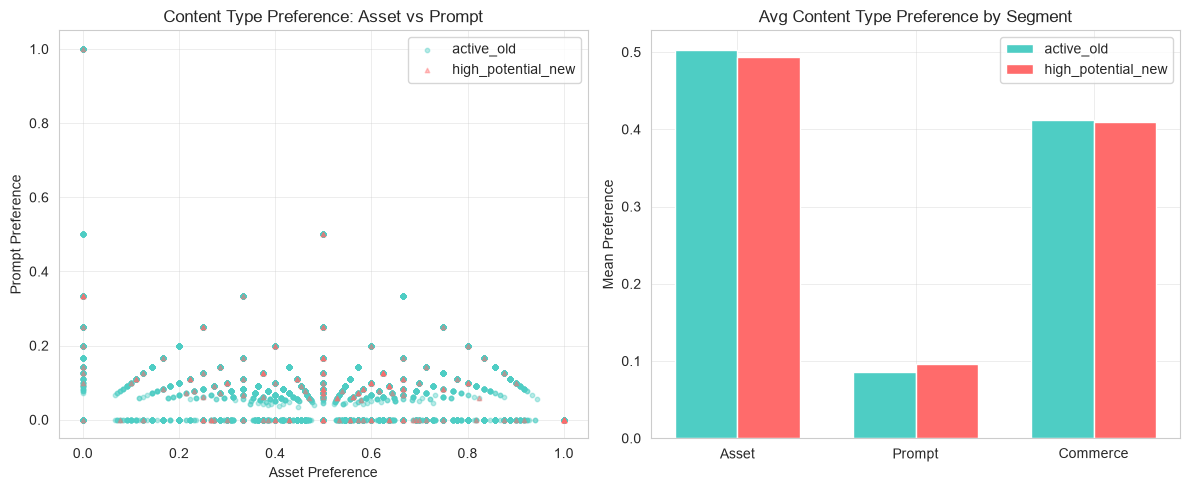

F1 content_type_pref stats:
       published_asset  published_prompt  published_commerce
count      6006.000000       6006.000000         6006.000000
mean          0.502562          0.086033            0.411404
std           0.259706          0.116066            0.258553
min           0.000000          0.000000            0.000000
25%           0.333333          0.000000            0.222222
50%           0.500000          0.076923            0.416667
75%           0.666667          0.125000            0.600000
max           1.000000          1.000000            1.000000


In [4]:
# F1: content_type_pref — 从用户 item 的 content_type 分布提取
ct_types = ['published_asset', 'published_prompt', 'published_commerce']
f1 = pd.DataFrame(index=users['user_id'], columns=ct_types, dtype=float)

for uid, data in user_items.items():
    if data is None:
        f1.loc[uid] = [1/3, 1/3, 1/3]  # 无数据的用户给均匀分布
    else:
        for ct in ct_types:
            f1.loc[uid, ct] = data['ct_dist'].get(ct, 0.0)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 三元分布散点（用 asset vs prompt 二维投影）
for seg, color, marker in [('active_old', '#4ECDC4', 'o'), ('high_potential_new', '#FF6B6B', '^')]:
    mask = users['user_segment'] == seg
    seg_f1 = f1.loc[users.loc[mask, 'user_id']]
    axes[0].scatter(seg_f1['published_asset'], seg_f1['published_prompt'], 
                    c=color, marker=marker, alpha=0.4, s=10, label=seg)
axes[0].set_xlabel('Asset Preference')
axes[0].set_ylabel('Prompt Preference')
axes[0].set_title('Content Type Preference: Asset vs Prompt')
axes[0].legend()

# 每类偏好的均值对比
means_old = f1.loc[users.loc[users['user_segment']=='active_old', 'user_id']].mean()
means_new = f1.loc[users.loc[users['user_segment']=='high_potential_new', 'user_id']].mean()
x = np.arange(len(ct_types))
w = 0.35
axes[1].bar(x - w/2, [means_old[ct] for ct in ct_types], w, label='active_old', color='#4ECDC4')
axes[1].bar(x + w/2, [means_new[ct] for ct in ct_types], w, label='high_potential_new', color='#FF6B6B')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Asset', 'Prompt', 'Commerce'])
axes[1].set_ylabel('Mean Preference')
axes[1].set_title('Avg Content Type Preference by Segment')
axes[1].legend()

fig.tight_layout()
plt.show()

print('F1 content_type_pref stats:')
print(f1.describe())

---
## Factor 2: theme_affinity（~N 维）
用户对各个 theme 的归一化亲和度向量

Total unique themes: 7470
Mean themes per user: 8.2, Median: 8
Users with 0 themes: 15
Sparsity: 0.11%


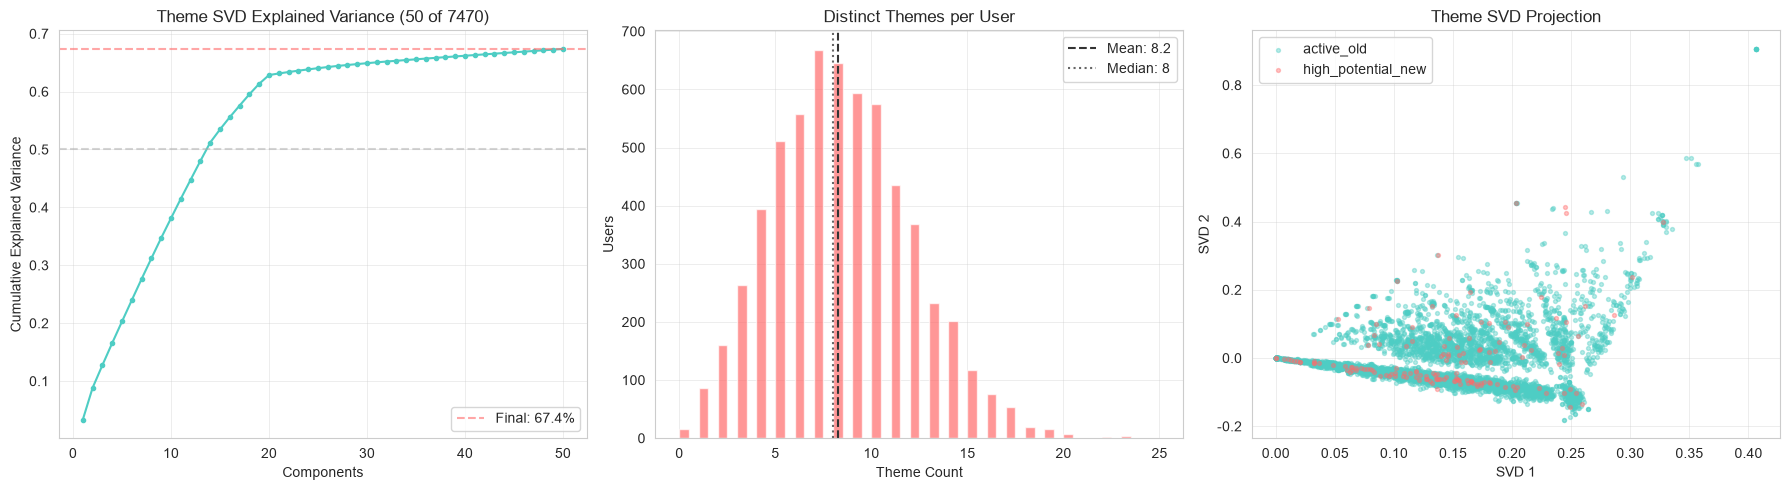

F2 theme_affinity: 6006 x 50
SVD cumulative explained variance: 67.4%


In [5]:
# F2: theme_affinity — 原始 theme 分布矩阵 → TruncatedSVD 降维到 50
from sklearn.decomposition import TruncatedSVD

all_themes = sorted(item_full['theme'].dropna().unique())
print(f'Total unique themes: {len(all_themes)}')

# 原始 theme 分布矩阵
f2_raw = pd.DataFrame(0.0, index=users['user_id'], columns=all_themes)
for uid, data in user_items.items():
    if data is None:
        continue
    for theme, weight in data['theme_dist'].items():
        if pd.notna(theme) and theme in f2_raw.columns:
            f2_raw.loc[uid, theme] = weight

# 稀疏度
non_zero = (f2_raw > 0).sum(axis=1)
print(f'Mean themes per user: {non_zero.mean():.1f}, Median: {non_zero.median():.0f}')
print(f'Users with 0 themes: {(non_zero == 0).sum()}')
sparsity = ((f2_raw > 0).sum().sum() / (f2_raw.shape[0] * f2_raw.shape[1])) * 100
print(f'Sparsity: {sparsity:.2f}%')

# TruncatedSVD 降维到 50
THEME_DIM = 50
svd = TruncatedSVD(n_components=THEME_DIM, random_state=42)
f2_arr = svd.fit_transform(f2_raw.values)
f2 = pd.DataFrame(
    f2_arr,
    index=users['user_id'],
    columns=[f'theme_svd_{i}' for i in range(THEME_DIM)]
)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 累积解释方差
cumsum_var = np.cumsum(svd.explained_variance_ratio_)
axes[0].plot(range(1, THEME_DIM + 1), cumsum_var, marker='o', markersize=3, color='#4ECDC4')
axes[0].axhline(y=0.5, color='#aaa', linestyle='--', alpha=0.5)
axes[0].axhline(y=cumsum_var[-1], color='#FF6B6B', linestyle='--', alpha=0.6,
                label=f'Final: {cumsum_var[-1]*100:.1f}%')
axes[0].set_xlabel('Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title(f'Theme SVD Explained Variance ({THEME_DIM} of {len(all_themes)})')
axes[0].legend()

# 用户 theme 数量分布
axes[1].hist(non_zero, bins=50, color='#FF6B6B', alpha=0.7)
axes[1].axvline(non_zero.mean(), color='#333', linestyle='--', label=f'Mean: {non_zero.mean():.1f}')
axes[1].axvline(non_zero.median(), color='#666', linestyle=':', label=f'Median: {non_zero.median():.0f}')
axes[1].set_title('Distinct Themes per User')
axes[1].set_xlabel('Theme Count')
axes[1].set_ylabel('Users')
axes[1].legend()

# SVD 前两维投影
for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    axes[2].scatter(f2.loc[seg_ids, 'theme_svd_0'], f2.loc[seg_ids, 'theme_svd_1'],
                    c=color, alpha=0.4, s=8, label=seg)
axes[2].set_xlabel('SVD 1')
axes[2].set_ylabel('SVD 2')
axes[2].set_title('Theme SVD Projection')
axes[2].legend()

fig.tight_layout()
plt.show()

print(f'F2 theme_affinity: {f2.shape[0]} x {f2.shape[1]}')
print(f'SVD cumulative explained variance: {cumsum_var[-1]*100:.1f}%')

---
## Factor 3: quality_sensitivity（1 维）
用户对内容质量的敏感程度 = 用户 rate 与其持有 item 质量的 Spearman 相关性

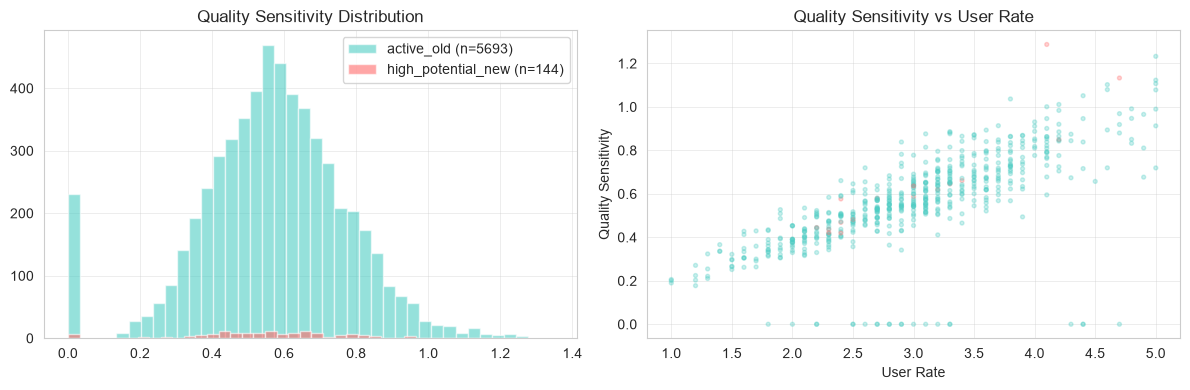

F3 quality_sensitivity stats:
       quality_sensitivity
count          5837.000000
mean              0.567026
std               0.209176
min               0.000000
25%               0.449730
50%               0.571506
75%               0.694182
max               1.344498


In [6]:
# F3: quality_sensitivity
# 用户 rate（来自画像）vs 其持有 item 的平均 quality（like/fav/comment/share_rate 均值）
# 有足够 item 的用户：计算 item quality 的均值和方差，看用户 rate 是否与 quality 相关
# 这里用简化方法：用户持有 item 的平均 quality × 用户自身 rate 的标准化偏差

f3 = pd.DataFrame(index=users['user_id'], columns=['quality_sensitivity'], dtype=float)

for uid, data in user_items.items():
    if data is None or len(data['item_quality']) < 3:
        f3.loc[uid, 'quality_sensitivity'] = 0.0  # 无数据用户给中性值
    else:
        # 用户 item 的平均 quality
        mean_q = data['item_quality'].mean()
        # quality 方差大 → 用户对质量不敏感（啥都收）；方差小且均值高 → 敏感
        std_q = data['item_quality'].std()
        # sensitivity = 低方差 + 高均值 = 挑剔
        # 用 mean / (1 + std) 近似，再用 rate 做加权
        raw_sensitivity = mean_q / (1 + std_q)
        # 用用户的 rate 缩放（rate 高的用户要求更高）
        user_rate = users.loc[users['user_id'] == uid, 'rate'].values[0]
        if pd.notna(user_rate):
            f3.loc[uid, 'quality_sensitivity'] = raw_sensitivity * (user_rate / 3.0)  # 3.0 = 中性 rate
        else:
            f3.loc[uid, 'quality_sensitivity'] = raw_sensitivity

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    vals = f3.loc[seg_ids, 'quality_sensitivity'].dropna()
    axes[0].hist(vals, bins=40, alpha=0.6, label=f'{seg} (n={len(vals)})', color=color)
axes[0].set_title('Quality Sensitivity Distribution')
axes[0].legend()

# quality_sensitivity vs user rate scatter
sample_ids = users['user_id'].iloc[::10]  # 每 10 个取 1 个
axes[1].scatter(
    users.loc[users['user_id'].isin(sample_ids), 'rate'],
    f3.loc[sample_ids, 'quality_sensitivity'],
    c=users.loc[users['user_id'].isin(sample_ids), 'user_segment'].map({'active_old': '#4ECDC4', 'high_potential_new': '#FF6B6B'}),
    alpha=0.3, s=8
)
axes[1].set_xlabel('User Rate')
axes[1].set_ylabel('Quality Sensitivity')
axes[1].set_title('Quality Sensitivity vs User Rate')

fig.tight_layout()
plt.show()

print('F3 quality_sensitivity stats:')
print(f3.describe())

---
## Factor 4: budget_level（1 维）
用户的消费/预算等级，综合 level + item 平均价格

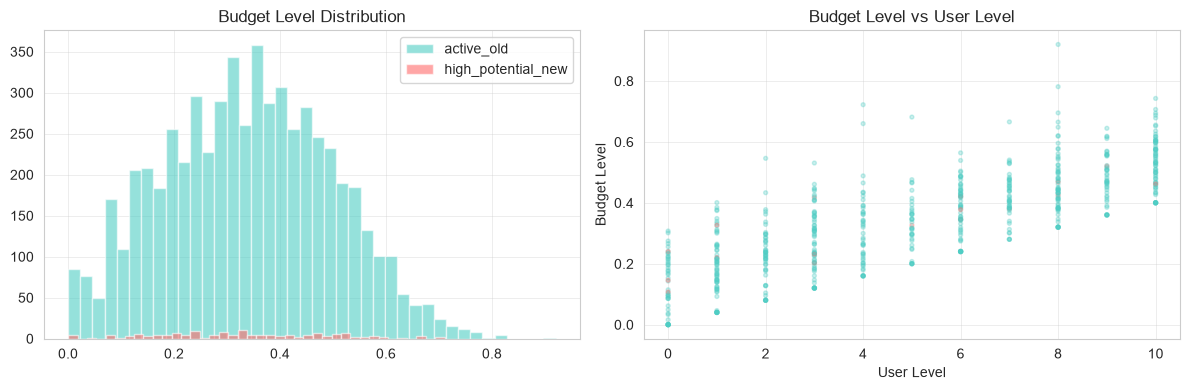

F4 budget_level stats:
       budget_level
count   6006.000000
mean       0.338631
std        0.158872
min        0.000067
25%        0.218942
50%        0.340259
75%        0.453838
max        0.920000


In [7]:
# F4: budget_level
# 来源1: user.level（用户的平台等级 0-10）
# 来源2: 用户持有 item 的平均 pricing
# 两者归一化后加权平均

f4 = pd.DataFrame(index=users['user_id'], columns=['budget_level'], dtype=float)

# 归一化 level
level_norm = (users.set_index('user_id')['level'] - users['level'].min()) / (users['level'].max() - users['level'].min())

# 归一化 avg_price
avg_prices = pd.Series(index=users['user_id'], dtype=float)
for uid, data in user_items.items():
    if data is not None and pd.notna(data['avg_price']):
        avg_prices[uid] = data['avg_price']
    else:
        avg_prices[uid] = np.nan

price_norm = (avg_prices - avg_prices.min()) / (avg_prices.max() - avg_prices.min())

# 加权：level 权重 0.4，price 权重 0.6（价格更能反映真实消费水平）
f4['budget_level'] = (0.4 * level_norm.fillna(0.5) + 0.6 * price_norm.fillna(0.5)).values

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    vals = f4.loc[seg_ids, 'budget_level']
    axes[0].hist(vals, bins=40, alpha=0.6, label=f'{seg}', color=color)
axes[0].set_title('Budget Level Distribution')
axes[0].legend()

# budget_level vs user level scatter
sample_ids = users['user_id'].iloc[::10]
axes[1].scatter(
    users.loc[users['user_id'].isin(sample_ids), 'level'],
    f4.loc[sample_ids, 'budget_level'],
    c=users.loc[users['user_id'].isin(sample_ids), 'user_segment'].map({'active_old': '#4ECDC4', 'high_potential_new': '#FF6B6B'}),
    alpha=0.3, s=8
)
axes[1].set_xlabel('User Level')
axes[1].set_ylabel('Budget Level')
axes[1].set_title('Budget Level vs User Level')

fig.tight_layout()
plt.show()

print('F4 budget_level stats:')
print(f4.describe())

---
## Factor 5: skill_match_vector（~32 维）
用户技能向量，从 goodat 文本 TF-IDF 提取

Users with non-empty goodat: 6,006
Sample goodat entries:
  [1] raw="达芬奇调色" -> ['达芬奇调色']
  [2] raw="绿幕抠像" -> ['绿幕抠像']
  [3] raw="视频剪辑与后期调色" -> ['视频剪辑与后期调色']
  [4] raw="产品摄影" -> ['产品摄影']
  [5] raw="PR剪辑精修" -> ['PR剪辑精修']

Total skill tokens: 6,006
Unique skill tokens: 1,830
Top 20 skills: [('达芬奇调色', 212), ('视频剪辑', 144), ('绿幕抠像', 128), ('无人机航拍', 114), ('延时摄影', 104), ('直播推流', 85), ('短视频脚本策划', 74), ('绿幕抠像合成', 72), ('多机位剪辑', 65), ('微电影导演', 63), ('字幕制作', 56), ('特效合成', 53), ('后期调色', 51), ('AE特效合成', 49), ('绿幕抠像与合成', 48), ('视频剪辑与后期制作', 40), ('转场设计', 39), ('视频剪辑与调色', 39), ('灯光布光', 38), ('Vlog拍摄', 38)]

TF-IDF matrix shape: (6006, 32)
Top features: ['ae特效合成', 'mg动画制作', 'pr剪辑', 'vlog拍摄', '分镜设计', '动画制作', '后期调色', '多机位剪辑', '字幕制作', '字幕包装', '延时摄影', '微电影导演', '无人机航拍', '灯光布光', '特效合成', '直播推流', '直播推流与obs设置', '直播推流与导播', '短视频策划', '短视频编导']


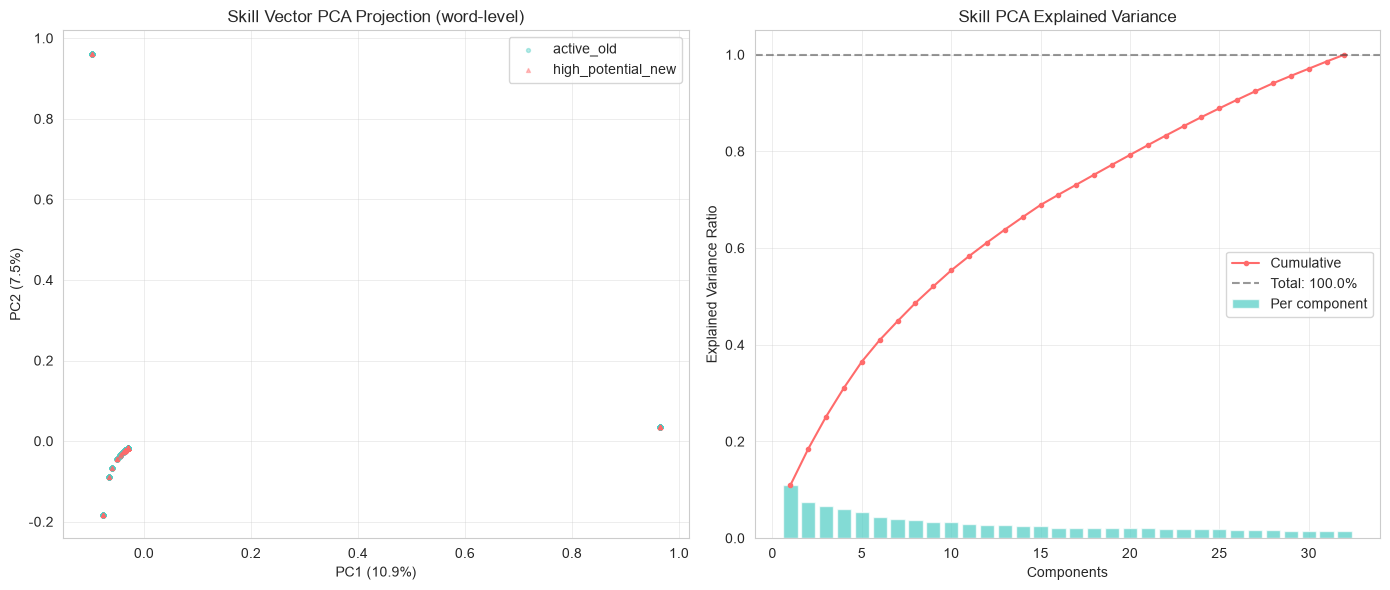

PCA explained variance (32 comps): 100.0%


In [8]:
# F5: skill_match_vector — goodat 文本按技能分词后 word-level TF-IDF
# goodat 中的技能用 \n / 逗号 / 顿号 / 分号分隔，先拆成技能短语再 TF-IDF
import re

def tokenize_goodat(text):
    return [t.strip() for t in re.split(r'[\n,，、；;]+', text) if t.strip() and len(t.strip()) >= 2]

goodat_texts = users['goodat'].fillna('')
print(f'Users with non-empty goodat: {(goodat_texts != "").sum():,}')
print(f'Sample goodat entries:')
for i, (_, row) in enumerate(users[users['goodat'].notna() & (users['goodat'] != '')].head(5).iterrows()):
    tokens = tokenize_goodat(row['goodat'])
    print(f'  [{i+1}] raw="{row["goodat"][:60]}" -> {tokens}')

# 展示技能 token 的统计
all_tokens = []
for text in goodat_texts:
    all_tokens.extend(tokenize_goodat(text))
token_freq = Counter(all_tokens)
print(f'\nTotal skill tokens: {len(all_tokens):,}')
print(f'Unique skill tokens: {len(token_freq):,}')
print(f'Top 20 skills: {token_freq.most_common(20)}')

# Word-level TF-IDF
tfidf = TfidfVectorizer(
    max_features=32,
    analyzer='word',
    tokenizer=tokenize_goodat,
    sublinear_tf=True
)
f5_raw = tfidf.fit_transform(goodat_texts)
print(f'\nTF-IDF matrix shape: {f5_raw.shape}')
print(f'Top features: {tfidf.get_feature_names_out()[:20].tolist()}')

# 转为 DataFrame
f5 = pd.DataFrame(
    f5_raw.toarray(),
    index=users['user_id'],
    columns=[f'skill_{i}' for i in range(f5_raw.shape[1])]
)

# PCA — 跑全 32 分量，散点图只取前两维
from sklearn.decomposition import PCA
N_SKILL_COMP = f5.shape[1]  # 32
pca = PCA(n_components=N_SKILL_COMP)
f5_pca_all = pca.fit_transform(f5.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for seg, color, marker in [('active_old', '#4ECDC4', 'o'), ('high_potential_new', '#FF6B6B', '^')]:
    mask = users['user_segment'] == seg
    idx = np.where(mask)[0]
    axes[0].scatter(f5_pca_all[idx, 0], f5_pca_all[idx, 1], c=color, marker=marker, alpha=0.4, s=8, label=seg)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Skill Vector PCA Projection (word-level)')
axes[0].legend()

# 累积方差
cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[1].bar(range(1, N_SKILL_COMP + 1), pca.explained_variance_ratio_, color='#4ECDC4', alpha=0.7, label='Per component')
axes[1].plot(range(1, N_SKILL_COMP + 1), cumsum, 'o-', color='#FF6B6B', markersize=3, label='Cumulative')
axes[1].axhline(y=cumsum[-1], color='#333', linestyle='--', alpha=0.5,
                label=f'Total: {cumsum[-1]*100:.1f}%')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Skill PCA Explained Variance')
axes[1].legend()

fig.tight_layout()
plt.show()

print(f'PCA explained variance ({N_SKILL_COMP} comps): {cumsum[-1]*100:.1f}%')

---
## Factor 6: activity_level（1 维）
用户整体活跃度，从社交计数归一化

Activity columns missing rate:
  fans_count: 0.0%
  follow_count: 0.0%
  liked_count: 0.0%
  fav_count: 0.0%
  comment_count: 0.0%
  shared_count: 0.0%


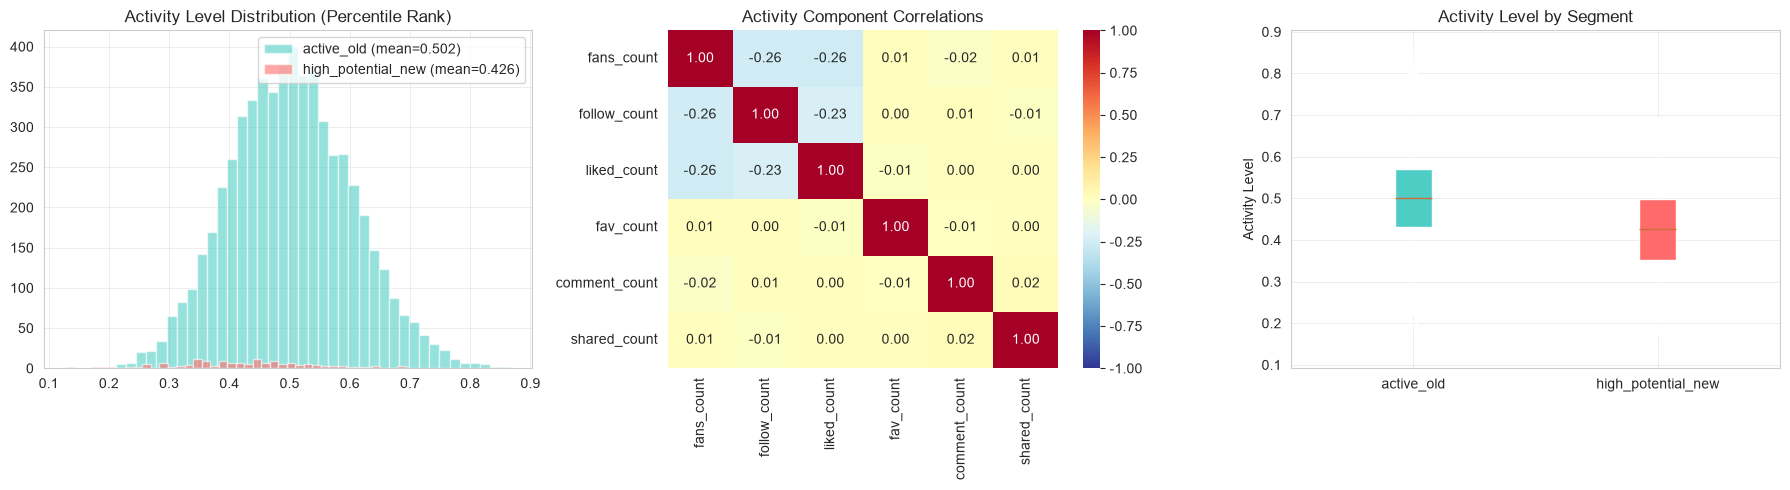

F6 activity_level stats:
       activity_level
count     6006.000000
mean         0.500083
std          0.102150
min          0.128580
25%          0.429182
50%          0.497877
75%          0.568643
max          0.866397

Mean activity_level by segment:
  active_old: mean=0.5019, std=0.1012, min=0.1949, max=0.8664
  high_potential_new: mean=0.4263, std=0.1105, min=0.1286, max=0.6931


In [9]:
# F6: activity_level — 用分位数排名代替线性归一化，增强区分度
activity_cols = ['fans_count', 'follow_count', 'liked_count', 'fav_count', 'comment_count', 'shared_count']

# 检查缺失
print('Activity columns missing rate:')
for col in activity_cols:
    print(f'  {col}: {users[col].isna().mean()*100:.1f}%')

# log1p 变换 → 分位数排名 → 均值
# 分位数排名把值均匀拉到 [0, 1]，避免幂律分布挤在一起
activity_log = np.log1p(users[activity_cols].fillna(0))
activity_pct = activity_log.rank(pct=True)  # percentile rank: [0, 1]

f6 = pd.DataFrame(index=users['user_id'])
f6['activity_level'] = activity_pct.mean(axis=1).values

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 分布
for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    vals = f6.loc[seg_ids, 'activity_level']
    axes[0].hist(vals, bins=40, alpha=0.6, label=f'{seg} (mean={vals.mean():.3f})', color=color)
axes[0].set_title('Activity Level Distribution (Percentile Rank)')
axes[0].legend()

# 各 activity 分量的相关性
corr = activity_pct.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Activity Component Correlations')

# segment 对比箱线图
seg_data = []
seg_labels = []
for seg in ['active_old', 'high_potential_new']:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    seg_data.append(f6.loc[seg_ids, 'activity_level'].values)
    seg_labels.append(seg)
bp = axes[2].boxplot(seg_data, tick_labels=seg_labels, patch_artist=True)
bp['boxes'][0].set_facecolor('#4ECDC4')
bp['boxes'][1].set_facecolor('#FF6B6B')
axes[2].set_title('Activity Level by Segment')
axes[2].set_ylabel('Activity Level')

fig.tight_layout()
plt.show()

print('F6 activity_level stats:')
print(f6.describe())

print('\nMean activity_level by segment:')
for seg in ['active_old', 'high_potential_new']:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    v = f6.loc[seg_ids, 'activity_level']
    print(f'  {seg}: mean={v.mean():.4f}, std={v.std():.4f}, min={v.min():.4f}, max={v.max():.4f}')

---
## Factor 7: social_tendency（1 维）
用户社交倾向 = comment / share 比例，反映偏互动还是偏传播

F7 valid: 6,006 users, NaN: 0, zero: 7
F7 range: [0.0000, 1.0000]


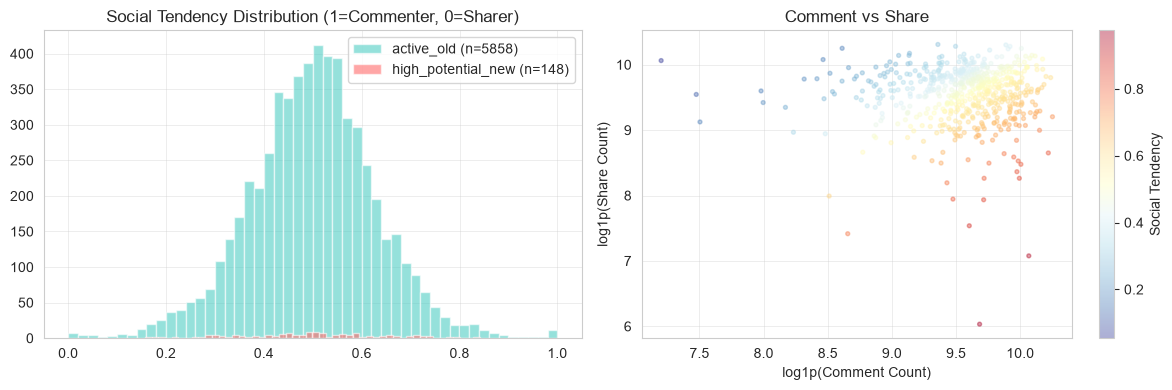

F7 stats:
       social_tendency
count      6006.000000
mean          0.498675
std           0.129490
min           0.000000
25%           0.420326
50%           0.501341
75%           0.579501
max           0.999955
  active_old: mean=0.4988, n=5858
  high_potential_new: mean=0.4933, n=148


In [10]:
# F7: social_tendency - comment / (comment + share + 1), 接近 1 = 评论型, 接近 0 = 分享型
# 用 pd.to_numeric 确保列是数值，避免 string/object dtype 导致全 NaN
f7 = pd.DataFrame(index=users["user_id"], columns=["social_tendency"], dtype=float)
comment = pd.to_numeric(users["comment_count"], errors='coerce').fillna(0)
share = pd.to_numeric(users["shared_count"], errors='coerce').fillna(0)
f7["social_tendency"] = (comment / (comment + share + 1)).values

# 验证数据有效性
n_nan = f7["social_tendency"].isna().sum()
n_zero = (f7["social_tendency"] == 0).sum()
print(f"F7 valid: {len(f7) - n_nan:,} users, NaN: {n_nan}, zero: {n_zero}")
print(f"F7 range: [{f7['social_tendency'].min():.4f}, {f7['social_tendency'].max():.4f}]")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for seg, color in [("active_old", "#4ECDC4"), ("high_potential_new", "#FF6B6B")]:
    mask = users["user_segment"] == seg
    seg_ids = users.loc[mask, "user_id"]
    vals = f7.loc[seg_ids, "social_tendency"].dropna()
    if len(vals) == 0 or vals.isna().all():
        print(f"WARNING: {seg} has no valid F7 values, skipping hist")
        continue
    vals_clean = vals.replace([np.inf, -np.inf], np.nan).dropna()
    axes[0].hist(vals_clean, bins=50, alpha=0.6, label=f"{seg} (n={len(vals_clean)})", color=color)

axes[0].set_title("Social Tendency Distribution (1=Commenter, 0=Sharer)")
axes[0].legend()

# scatter: 从 f7 index 直接取 user_id，避免 index 对齐问题
valid_uids = f7.loc[f7["social_tendency"].notna()].index[::10]
comment_sample = comment.loc[users["user_id"].isin(valid_uids)].values
share_sample = share.loc[users["user_id"].isin(valid_uids)].values
c_sample = f7.loc[valid_uids, "social_tendency"].values

sc = axes[1].scatter(
    np.log1p(comment_sample),
    np.log1p(share_sample),
    c=c_sample,
    cmap="RdYlBu_r", alpha=0.4, s=8
)
axes[1].set_xlabel("log1p(Comment Count)")
axes[1].set_ylabel("log1p(Share Count)")
axes[1].set_title("Comment vs Share")
plt.colorbar(sc, ax=axes[1], label="Social Tendency")

fig.tight_layout()
plt.show()

print("F7 stats:")
print(f7.describe())
for seg in ["active_old", "high_potential_new"]:
    mask = users["user_segment"] == seg
    seg_ids = users.loc[mask, "user_id"]
    v = f7.loc[seg_ids, "social_tendency"].dropna()
    print(f"  {seg}: mean={v.mean():.4f}, n={len(v)}")

In [11]:
# --- F7 诊断：排查 social_tendency 为什么全 NaN ---
print('=== F7 Debug ===')

# 直接检查原始列
for col in ['comment_count', 'shared_count']:
    raw = users[col]
    print(f'\n{col}:')
    print(f'  dtype = {raw.dtype}')
    print(f'  NaN count = {raw.isna().sum()}')
    print(f'  sample values (first 5): {raw.head(5).tolist()}')
    print(f'  sample types: {[type(x).__name__ for x in raw.head(5)]}')
    
    # Try conversion
    numeric = pd.to_numeric(raw, errors='coerce')
    print(f'  after pd.to_numeric: NaN={numeric.isna().sum()}, min={numeric.min()}, max={numeric.max()}')

# Test the exact F7 computation on first 10 rows
print('\n=== Step-by-step test (first 10 rows) ===')
c = users['comment_count'].head(10)
s = users['shared_count'].head(10)
print(f'comment raw: {c.tolist()}')
print(f'share raw: {s.tolist()}')
c_filled = c.fillna(0)
s_filled = s.fillna(0)
print(f'comment filled: {c_filled.tolist()}')
print(f'share filled: {s_filled.tolist()}')
result = c_filled / (c_filled + s_filled + 1)
print(f'result: {result.tolist()}')

=== F7 Debug ===

comment_count:
  dtype = int64
  NaN count = 0
  sample values (first 5): [15170, 18364, 22450, 6501, 15202]
  sample types: ['int', 'int', 'int', 'int', 'int']
  after pd.to_numeric: NaN=0, min=0, max=30000

shared_count:
  dtype = int64
  NaN count = 0
  sample values (first 5): [19669, 16900, 13333, 14602, 15589]
  sample types: ['int', 'int', 'int', 'int', 'int']
  after pd.to_numeric: NaN=0, min=0, max=30000

=== Step-by-step test (first 10 rows) ===
comment raw: [15170, 18364, 22450, 6501, 15202, 8552, 10147, 20754, 14270, 17309]
share raw: [19669, 16900, 13333, 14602, 15589, 14288, 7499, 10566, 20558, 13073]
comment filled: [15170, 18364, 22450, 6501, 15202, 8552, 10147, 20754, 14270, 17309]
share filled: [19669, 16900, 13333, 14602, 15589, 14288, 7499, 10566, 20558, 13073]
result: [0.4354190585533869, 0.5207429462640011, 0.6273753632908563, 0.3080458680818802, 0.49369966224993506, 0.37441443019132264, 0.5749985833286111, 0.6626225216308547, 0.4097160412300095,

In [12]:
# 组装全部 factor
# F1: 3 维, F2: N_themes 维, F3: 1 维, F4: 1 维, F5: 32 维, F6: 1 维, F7: 1 维

user_latent = pd.concat([
    f1.add_prefix('ct_'),
    f2.add_prefix('theme_'),
    f3,
    f4,
    f5,
    f6,
    f7,
], axis=1)

print(f'User latent matrix: {user_latent.shape}')
print(f'Columns: {list(user_latent.columns[:10])}... ({len(user_latent.columns)} total)')
print(f'NaN rate: {user_latent.isna().mean().mean()*100:.2f}%')

# 按 segment 分开看
for seg in ['active_old', 'high_potential_new']:
    mask = users['user_segment'] == seg
    seg_ids = users.loc[mask, 'user_id']
    seg_latent = user_latent.loc[seg_ids]
    print(f'\n{seg}: {len(seg_latent)} users')
    print(f'  NaN rate: {seg_latent.isna().mean().mean()*100:.2f}%')
    # 检查全零行
    zero_rows = (seg_latent.fillna(0).abs().sum(axis=1) == 0).sum()
    print(f'  All-zero rows: {zero_rows}')

user_latent.head()

User latent matrix: (6006, 89)
Columns: ['ct_published_asset', 'ct_published_prompt', 'ct_published_commerce', 'theme_theme_svd_0', 'theme_theme_svd_1', 'theme_theme_svd_2', 'theme_theme_svd_3', 'theme_theme_svd_4', 'theme_theme_svd_5', 'theme_theme_svd_6']... (89 total)
NaN rate: 0.03%

active_old: 5858 users
  NaN rate: 0.03%
  All-zero rows: 0

high_potential_new: 148 users
  NaN rate: 0.03%
  All-zero rows: 0


,ct_published_asset,ct_published_prompt,ct_published_commerce,theme_theme_svd_0,theme_theme_svd_1,theme_theme_svd_2,theme_theme_svd_3,theme_theme_svd_4,theme_theme_svd_5,theme_theme_svd_6,...,skill_24,skill_25,skill_26,skill_27,skill_28,skill_29,skill_30,skill_31,activity_level,social_tendency
user_id,,,,,,,,,,,,,,,,,,,,,
0009a79d-1d76-412e-854e-0cb636eb6687,0.500000,0.083333,0.416667,0.132346,-0.060138,-0.046362,-0.013900,-0.076988,-0.047875,-0.067932,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.493284,0.435419
0012bd9c-afde-4948-8372-a734d1d1bbdf,0.466667,0.066667,0.466667,0.121950,-0.060543,-0.054925,-0.084312,0.090491,0.002785,-0.047314,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.503330,0.520743
0024c0d3-68b5-4284-b8ac-c8804383d15a,0.500000,0.000000,0.500000,0.134260,-0.007547,0.047802,-0.009219,-0.025017,0.041322,-0.040016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.566184,0.627375
003ee291-33f7-46b6-baf2-b898002cf97c,0.555556,0.111111,0.333333,0.163726,0.057511,-0.031513,-0.051785,0.033256,0.032496,0.018277,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.312965,0.308046
005a687d-33ac-4624-8c82-b30064441da0,0.066667,0.066667,0.866667,0.021690,-0.009230,-0.000742,-0.014249,0.007434,0.002277,0.000204,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.493867,0.493700


In [13]:
# 保存 user_latent 供 Phase A-2 / A-3 使用
OUTPUT_DIR = '../data'
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

user_latent.to_csv(f'{OUTPUT_DIR}/user_latent.csv')
print(f'Saved user_latent ({user_latent.shape}) to {OUTPUT_DIR}/user_latent.csv')

# 同时保存一份 user_id → segment 映射
users[['user_id', 'user_segment']].to_csv(f'{OUTPUT_DIR}/user_segments.csv', index=False)
print(f'Saved user segments to {OUTPUT_DIR}/user_segments.csv')

Saved user_latent ((6006, 89)) to ../data/user_latent.csv
Saved user segments to ../data/user_segments.csv


---
## Phase A-1 结论

1. 各 factor 的分布是否合理？segment 间是否有区分度？
2. 全零行用户有多少？是否需要在 Phase A-3 做特殊处理？
3. theme 维度是否过于稀疏（用户人均 theme 数太少）？是否需要降维？

### 下一步：Phase A-2
构建 Item Latent Factors，与 user_latent 对齐到同一空间。